# Titanic Dataset - Exploratory Data Analysis and Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

The Titanic dataset is loaded and inspected to understand its structure and available features.

In [2]:
tit = pd.read_csv('Titanic-Dataset.csv')


## Initial Exploration

In this section, basic information such as dataset shape, column names, and summary statistics are examined.

In [3]:
print(tit.shape)
tit.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
tit.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
tit.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
tit.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
tit.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

## Missing Value Analysis

Before analysis, missing values are identified and handled appropriately.

In [8]:
tit.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Data Cleaning

Missing values in the Age column are replaced using the mean value. Other columns are checked to ensure data consistency.

In [9]:
# Fill missing values in Age
tit['Age'] = tit['Age'].fillna(tit['Age'].mean())

# Drop Cabin because it contains many missing values
tit.drop(columns=['Cabin'], inplace=True)

tit.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [10]:
tit.dropna(inplace = True)

In [11]:
print("Dataset Shape:", tit.shape)
tit.isnull().sum()

Dataset Shape: (889, 11)


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [12]:
tit.duplicated().sum()

np.int64(0)

In [13]:
print("The Shape Of Dataset after dropping duplicate is ", tit.shape)

The Shape Of Dataset after dropping duplicate is  (889, 11)


## Survival Analysis by Gender

This analysis examines whether passenger gender affected survival probability.

Sex
female    0.740385
male      0.188908
Name: Survived, dtype: float64


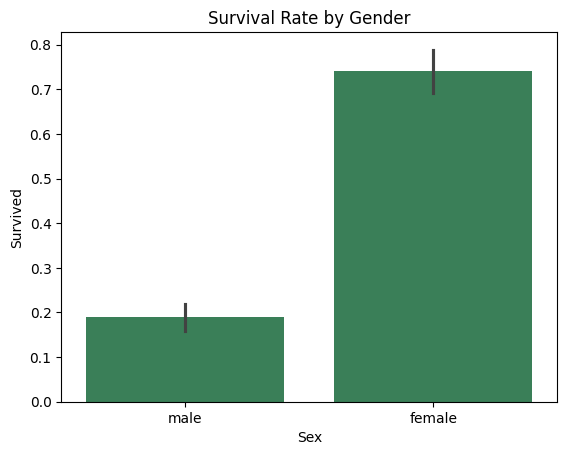

In [14]:
survival_gender = tit.groupby('Sex')['Survived'].mean()
print(survival_gender)

sns.barplot(x='Sex', y='Survived', data=tit, color="seagreen")
plt.title('Survival Rate by Gender')
plt.show()

### Observation

Female passengers had a significantly higher survival rate than male passengers, indicating that gender played an important role during evacuation.

## Survival Analysis by Passenger Class

Passenger class may have influenced access to safety measures during the disaster.

Pclass
1    0.626168
2    0.472826
3    0.242363
Name: Survived, dtype: float64


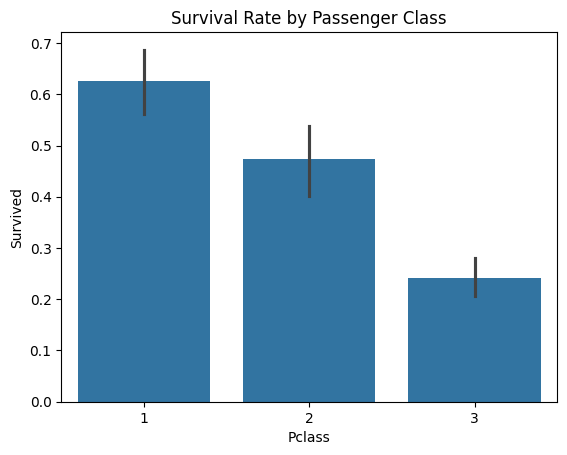

In [15]:
survival_class = tit.groupby('Pclass')['Survived'].mean()
print(survival_class)

sns.barplot(x='Pclass', y='Survived', data=tit)
plt.title('Survival Rate by Passenger Class')
plt.show()

### Observation

Passengers travelling in first class had the highest survival rate, while third-class passengers had the lowest survival probability.

## Age Distribution

The age distribution of passengers is visualized to understand the demographic composition of the dataset.

AgeGroup
Child          0.579710
Teen           0.428571
Young Adult    0.353271
Adult          0.396907
Senior         0.190476
Name: Survived, dtype: float64


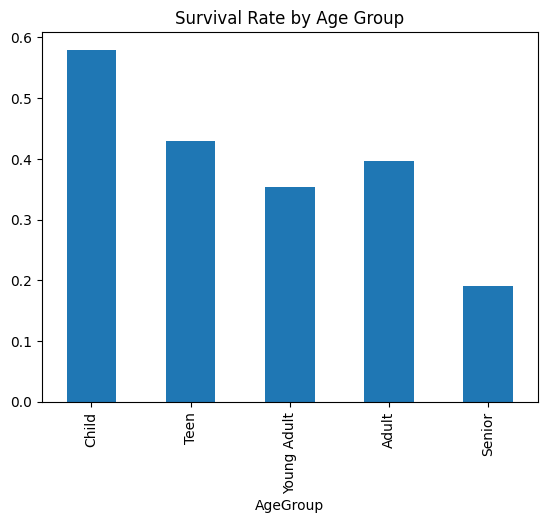

In [16]:
bins = [0,12,18,35,60,100]
labels = ['Child','Teen','Young Adult','Adult','Senior']

tit['AgeGroup'] = pd.cut(tit['Age'], bins=bins, labels=labels)

age_survival = tit.groupby('AgeGroup')['Survived'].mean()

print(age_survival)

age_survival.plot(kind='bar')
plt.title('Survival Rate by Age Group')
plt.show()

### Observation

Most passengers belonged to the young and middle-aged categories. Children formed only a small portion of the dataset.

## Age Histogram

A histogram is used to visualize the distribution of passenger ages and identify the most common age ranges.

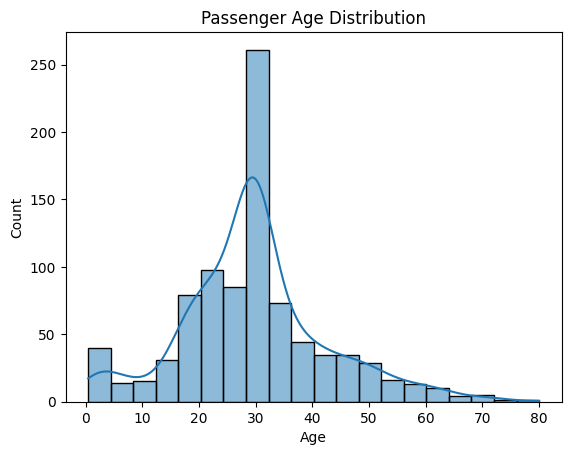

In [17]:
sns.histplot(tit['Age'], bins=20, kde=True)
plt.title('Passenger Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

## Passenger Class Distribution

This visualization shows how passengers were distributed among different ticket classes.

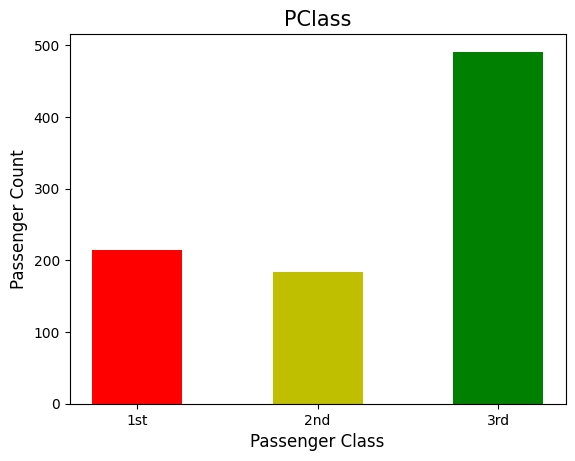

In [18]:
Pc_count = tit['Pclass'].value_counts()
x = ["1st" , "2nd" , "3rd"]
y = [Pc_count[1] , Pc_count[2] , Pc_count[3]]
c = ["r" , "y" , "g"]

plt.xlabel("Passenger Class", fontsize = 12)
plt.ylabel("Passenger Count" , fontsize =12)
plt.title("PClass" , fontsize =15)
plt.bar(x,y, color =c , width =0.5)
plt.show()

### Observation

The majority of passengers travelled in third class, followed by first and second class.

## Correlation Analysis

A correlation heatmap is used to identify relationships among numerical variables.

In [19]:
correlation = tit.select_dtypes(include=['number']).corr()

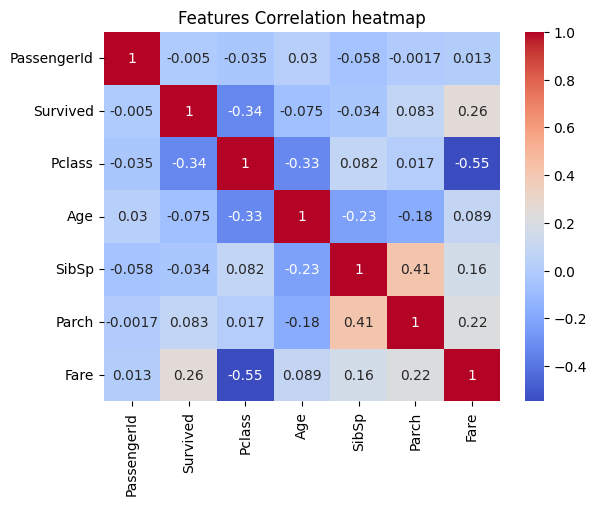

In [20]:
sns.heatmap(correlation , annot = True , cmap = 'coolwarm')
plt.title("Features Correlation heatmap")
plt.show()

### Observation

Fare shows a moderate positive relationship with survival, while passenger class is negatively correlated with survival.

## Feature Engineering

In [21]:
tit['FamilySize'] = tit['SibSp'] + tit['Parch'] + 1

tit['IsAlone'] = (tit['FamilySize'] == 1).astype(int)

tit[['FamilySize','IsAlone']].head()

,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


### Observation

Family size and whether a passenger travelled alone may influence survival and can be useful engineered features.

## Survival Rate by Family Size

Family size is calculated using the number of siblings/spouses (SibSp) and parents/children (Parch) travelling together.

This analysis helps understand how travelling alone or with family influenced survival chances.

FamilySize
1     0.300935
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64


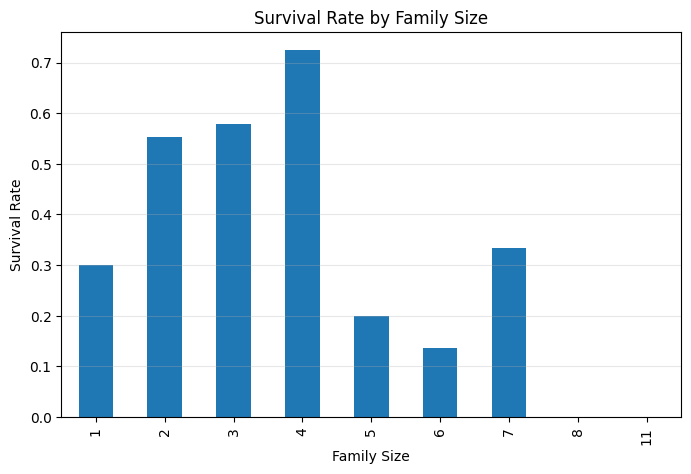

In [22]:
# Survival rate by family size

family_survival = tit.groupby("FamilySize")["Survived"].mean()

print(family_survival)

plt.figure(figsize=(8,5))

family_survival.plot(kind="bar")

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Observation

The survival rate varies across different family sizes. Passengers travelling in small to medium-sized families generally had a higher survival rate, while passengers travelling alone or with very large families tended to have lower survival rates.

# Survival Based on Embarkation Port

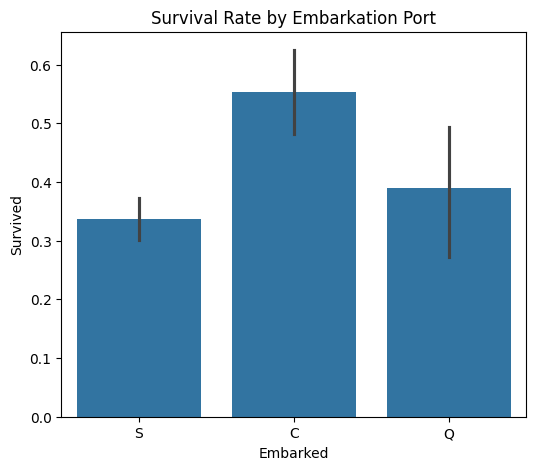

In [23]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=tit,
    x='Embarked',
    y='Survived'
)

plt.title("Survival Rate by Embarkation Port")
plt.show()

### Observation

Passengers boarding from different embarkation ports showed varying survival rates, suggesting embarkation location may influence survival.

# Age Group Analysis

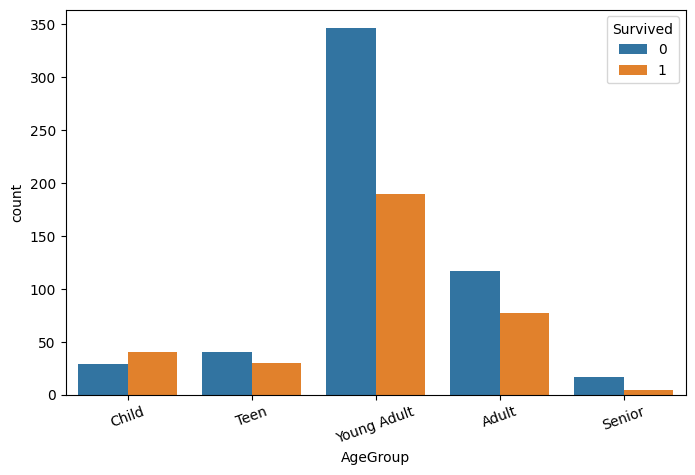

In [24]:
tit['AgeGroup'] = pd.cut(
    tit['Age'],
    bins=[0,12,18,35,60,100],
    labels=[
        'Child',
        'Teen',
        'Young Adult',
        'Adult',
        'Senior'
    ]
)

plt.figure(figsize=(8,5))

sns.countplot(
    data=tit,
    x='AgeGroup',
    hue='Survived'
)

plt.xticks(rotation=20)

plt.show()

### Observation

Young adults formed the largest group in the dataset. Survival varied across different age categories.

# Key Findings

- Female passengers had a significantly higher survival rate than male passengers.

- First-class passengers were more likely to survive than passengers in lower classes.

- Young adults represented the largest age group in the dataset.

- Survival rates varied with family size, indicating that travelling with a small family was generally associated with better survival.

- Survival rates also differed across embarkation ports.

- Feature engineering created **FamilySize**, **IsAlone**, and **AgeGroup** to support deeper exploratory analysis.

# Conclusion

The Titanic dataset was cleaned, explored and enhanced using feature engineering techniques. Important relationships between passenger characteristics and survival were identified through statistical analysis and visualizations. The engineered features such as FamilySize, IsAlone and AgeGroup provide additional information that can be used for predictive machine learning models.